In [1]:
# @title Package
from natsort import natsorted
import numpy as np
import seaborn as sns
import pandas as pd

import matplotlib.pyplot as plt
import os

import torch
import torch.nn as nn
import torch.nn.functional as F
import scipy as sp
import scipy.signal as signal
import torchaudio
import math
from sklearn import svm

import torchvision
import torchvision.transforms as transforms
import torchaudio.models as audio_models

from torch.utils.data import DataLoader
from torch.utils.data import TensorDataset

import time

lib_dir = '/content/drive/MyDrive/Project/BrainRegionId/Project44/Code'
os.chdir(lib_dir)
print('library directory: ' + lib_dir)
from modules.networks_clf import *
from modules.signal import spectro_norm, lfp_spectro
from modules.data import *
from modules.metrics import accu_fun

library directory: /content/drive/MyDrive/Project/BrainRegionId/Project44/Code


In [2]:
# @title Load device
dtype = torch.float
# Check whether GPU is available
if torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

!nvidia-smi -L


/bin/bash: line 1: nvidia-smi: command not found


In [3]:
!pip install networkx
import networkx as nx

In [4]:
# Set the signal parameters
spectro_args = {
    'nfft':800,
    'power':1,
    'LFP_bound':[0, 500],
    'MUA_bound':[500, 2000],
    'spectro_img':[224, 28],
    'LFP_img':[56 * 4, 28],
    'MUA_img':[0, 28],
    'sampling_lfp':2500,
    'sampling_mua':5000,
    'Log':False,
}

dict_dir = '/content/drive/MyDrive/Project/BrainRegionId/Project37/Data/dat'
acronym_list = acronym_list_gen(dict_dir)

In [5]:
community_dict = torch.load('/content/drive/MyDrive/Project/BrainRegionId/Science/results/communities/community_dict.pt', weights_only=False)

In [6]:
Mat_dict = torch.load('/content/drive/MyDrive/Project/BrainRegionId/Project44/Result/Confusion_mat.pt', weights_only=False)

In [7]:
communities_accu_indiv = torch.load('/content/drive/MyDrive/Project/BrainRegionId/Science/results/communities/communities_accu_indiv.pt', weights_only=False)


In [8]:
for acronym in acronym_list:
    if 'SC' in acronym:
        print(acronym)

VISC5
VISC6a
VISC6b
SCop
SCsg
SCzo
SCdg
SCdw
SCiw


In [9]:
community_dict[1.0]

{'communities': array([366, 380, 385, 386, 387, 388, 389, 390, 391, 393, 395, 396, 397,
        398, 399, 400, 401, 402, 403, 404, 405, 406, 407, 408, 409, 410,
        411, 413, 415, 417, 418, 419, 420, 454, 455, 456, 457, 458, 459,
        460, 461, 462, 463, 464, 465, 466, 467, 468, 469, 470, 471, 322,
        345, 369, 374, 375, 379,   3,   6,   7,   8,  12,  13,  33,  34,
         35,  36,  37,  61,  62, 127, 128, 129, 131, 132, 133, 134, 137,
        138, 139, 140, 141, 142, 143, 147, 150, 151, 155, 156, 157, 158,
        163, 164, 165, 166, 167, 226, 227, 236, 237,  99, 100, 101, 102,
        103, 108, 109, 116, 170, 171, 175, 176, 178, 225, 319, 320, 321,
         26,  27,  44,  87, 110, 111, 112, 113, 168, 169, 174, 177, 184,
        435,  22,  23, 105,  20,  21,  56,  57,  93,  94,  95,  96, 118,
        183, 195, 196, 146, 149, 425, 119, 199, 353, 120, 212, 217, 221,
        222, 223, 235, 267, 430, 431, 432, 433, 438,   0,   1, 144, 145,
        152, 153, 207, 208, 228, 422

In [11]:
resolution = 1.0
marked_community = []
for community in np.unique(community_dict[resolution]['communities_label']):
    df_indiv0 = communities_accu_indiv[resolution][communities_accu_indiv[resolution]['acronym_test'] == community]
    for classifier_name in ['AnyNet']:
        if df_indiv0[df_indiv0['model_type'] == classifier_name]['acu_test'].mean() > 0.0:
            marked_community.append(community)

# supplementary_community = []
# for acronym in ['SSs5', 'POST', 'TEa4', 'VISp1', 'VISa5', 'VISa4', 'ENTl2', 'MPO', 'PC5', 'SCop', 'SCsg', 'SCzo', 'SCdg', 'SCdw', 'SCiw']:
#     supplementary_community.append(community_dict[1.0]['communities_label'][np.argwhere(community_dict[1.0]['communities_acronym'] == acronym).flatten()])

marked_community = np.unique(np.array(marked_community))
select_community = marked_community
print(select_community)
print(marked_community)

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31]
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31]


In [12]:
color_list = sns.color_palette('tab20')
for color in sns.color_palette('Set3'):
    color_list.append(color)

for color in sns.color_palette('Set3'):
    if color in sns.color_palette('tab20'):
        print('Overlap')

In [13]:
acronym_index = []
label_index = []
color_list = sns.color_palette('tab20')
for color in sns.color_palette('Set3'):
    color_list.append(color)
acronym_name = []
for community_ii, community in enumerate(select_community):
    ind = np.argwhere(community_dict[resolution]['communities_label'] == community).flatten()
    # print('Community:')
    # print(community)
    # print('Allen:')
    # print(community_dict[resolution]['communities_acronym'][ind])
    acronym_index.append(community_dict[resolution]['communities'][ind])
    label_index.append(community_dict[resolution]['communities_label'][ind])
    acronym_name.append(community_dict[resolution]['communities_acronym'][ind])
acronym_index = np.concat(acronym_index)
label_index = np.concat(label_index)
acronym_name = np.concat(acronym_name)

In [14]:
color_list

[(0.12156862745098039, 0.4666666666666667, 0.7058823529411765),
 (0.6823529411764706, 0.7803921568627451, 0.9098039215686274),
 (1.0, 0.4980392156862745, 0.054901960784313725),
 (1.0, 0.7333333333333333, 0.47058823529411764),
 (0.17254901960784313, 0.6274509803921569, 0.17254901960784313),
 (0.596078431372549, 0.8745098039215686, 0.5411764705882353),
 (0.8392156862745098, 0.15294117647058825, 0.1568627450980392),
 (1.0, 0.596078431372549, 0.5882352941176471),
 (0.5803921568627451, 0.403921568627451, 0.7411764705882353),
 (0.7725490196078432, 0.6901960784313725, 0.8352941176470589),
 (0.5490196078431373, 0.33725490196078434, 0.29411764705882354),
 (0.7686274509803922, 0.611764705882353, 0.5803921568627451),
 (0.8901960784313725, 0.4666666666666667, 0.7607843137254902),
 (0.9686274509803922, 0.7137254901960784, 0.8235294117647058),
 (0.4980392156862745, 0.4980392156862745, 0.4980392156862745),
 (0.7803921568627451, 0.7803921568627451, 0.7803921568627451),
 (0.7372549019607844, 0.7411764705882353, 0.13333333333333333),
 (0.8588235294117647, 0.8588235294117647, 0.5529411764705883),
 (0.09019607843137255, 0.7450980392156863, 0.8117647058823529),
 (0.6196078431372549, 0.8549019607843137, 0.8980392156862745),
 (0.5529411764705883, 0.8274509803921568, 0.7803921568627451),
 (1.0, 1.0, 0.7019607843137254),
 (0.7450980392156863, 0.7294117647058823, 0.8549019607843137),
 (0.984313725490196, 0.5019607843137255, 0.4470588235294118),
 (0.5019607843137255, 0.6941176470588235, 0.8274509803921568),
 (0.9921568627450981, 0.7058823529411765, 0.3843137254901961),
 (0.7019607843137254, 0.8705882352941177, 0.4117647058823529),
 (0.9882352941176471, 0.803921568627451, 0.8980392156862745),
 (0.8509803921568627, 0.8509803921568627, 0.8509803921568627),
 (0.7372549019607844, 0.5019607843137255, 0.7411764705882353),
 (0.8, 0.9215686274509803, 0.7725490196078432),
 (1.0, 0.9294117647058824, 0.43529411764705883)]

In [15]:
acronym_name

array(['KF', 'I5', 'DCO', 'VCO', 'CU', 'ECU', 'SPVC', 'SPVI', 'Pa5',
       'AMBv', 'GRN', 'ICB', 'IO', 'IRN', 'LIN', 'LRNm', 'MARN', 'MDRNd',
       'MDRNv', 'PARN', 'PAS', 'PGRNd', 'PGRNl', 'PRP', 'LAV', 'MV',
       'SPIV', 'x', 'y', 'FN', 'IP', 'DN', 'VeCB', 'NTS', 'SPVO', 'LING',
       'CENT2', 'CENT3', 'CUL4 5', 'DEC', 'FOTU', 'PYR', 'UVU', 'NOD',
       'SIM', 'ANcr1', 'ANcr2', 'PRM', 'COPY', 'PFL', 'FL', 'ICc', 'CUN',
       'SOCl', 'PRNc', 'SUT', 'PC5', 'FRP6a', 'MOp5', 'MOp6a', 'MOp6b',
       'MOs6a', 'MOs6b', 'SSp-m2/3', 'SSp-m4', 'SSp-m5', 'SSp-m6a',
       'SSp-m6b', 'GU5', 'GU6a', 'ACAd5', 'ACAd6a', 'ACAd6b', 'ACAv2/3',
       'ACAv5', 'ACAv6a', 'ACAv6b', 'PL5', 'PL6a', 'PL6b', 'ILA1',
       'ILA2/3', 'ILA5', 'ILA6a', 'ORBl6a', 'ORBm5', 'ORBm6a', 'ORBvl6a',
       'AId5', 'AId6a', 'AId6b', 'AIp6b', 'AIv2/3', 'AIv5', 'AIv6a',
       'AIv6b', 'CLA', 'EPd', 'CP', 'ACB', 'VISp1', 'VISp2/3', 'VISp4',
       'VISp5', 'VISp6a', 'VISpl5', 'VISpl6a', 'VISli2/3', 'RSPagl5',
    

In [ ]:
sns.color_palette('tab20')

[(0.12156862745098039, 0.4666666666666667, 0.7058823529411765),
 (0.6823529411764706, 0.7803921568627451, 0.9098039215686274),
 (1.0, 0.4980392156862745, 0.054901960784313725),
 (1.0, 0.7333333333333333, 0.47058823529411764),
 (0.17254901960784313, 0.6274509803921569, 0.17254901960784313),
 (0.596078431372549, 0.8745098039215686, 0.5411764705882353),
 (0.8392156862745098, 0.15294117647058825, 0.1568627450980392),
 (1.0, 0.596078431372549, 0.5882352941176471),
 (0.5803921568627451, 0.403921568627451, 0.7411764705882353),
 (0.7725490196078432, 0.6901960784313725, 0.8352941176470589),
 (0.5490196078431373, 0.33725490196078434, 0.29411764705882354),
 (0.7686274509803922, 0.611764705882353, 0.5803921568627451),
 (0.8901960784313725, 0.4666666666666667, 0.7607843137254902),
 (0.9686274509803922, 0.7137254901960784, 0.8235294117647058),
 (0.4980392156862745, 0.4980392156862745, 0.4980392156862745),
 (0.7803921568627451, 0.7803921568627451, 0.7803921568627451),
 (0.7372549019607844, 0.7411764705882353, 0.13333333333333333),
 (0.8588235294117647, 0.8588235294117647, 0.5529411764705883),
 (0.09019607843137255, 0.7450980392156863, 0.8117647058823529),
 (0.6196078431372549, 0.8549019607843137, 0.8980392156862745)]

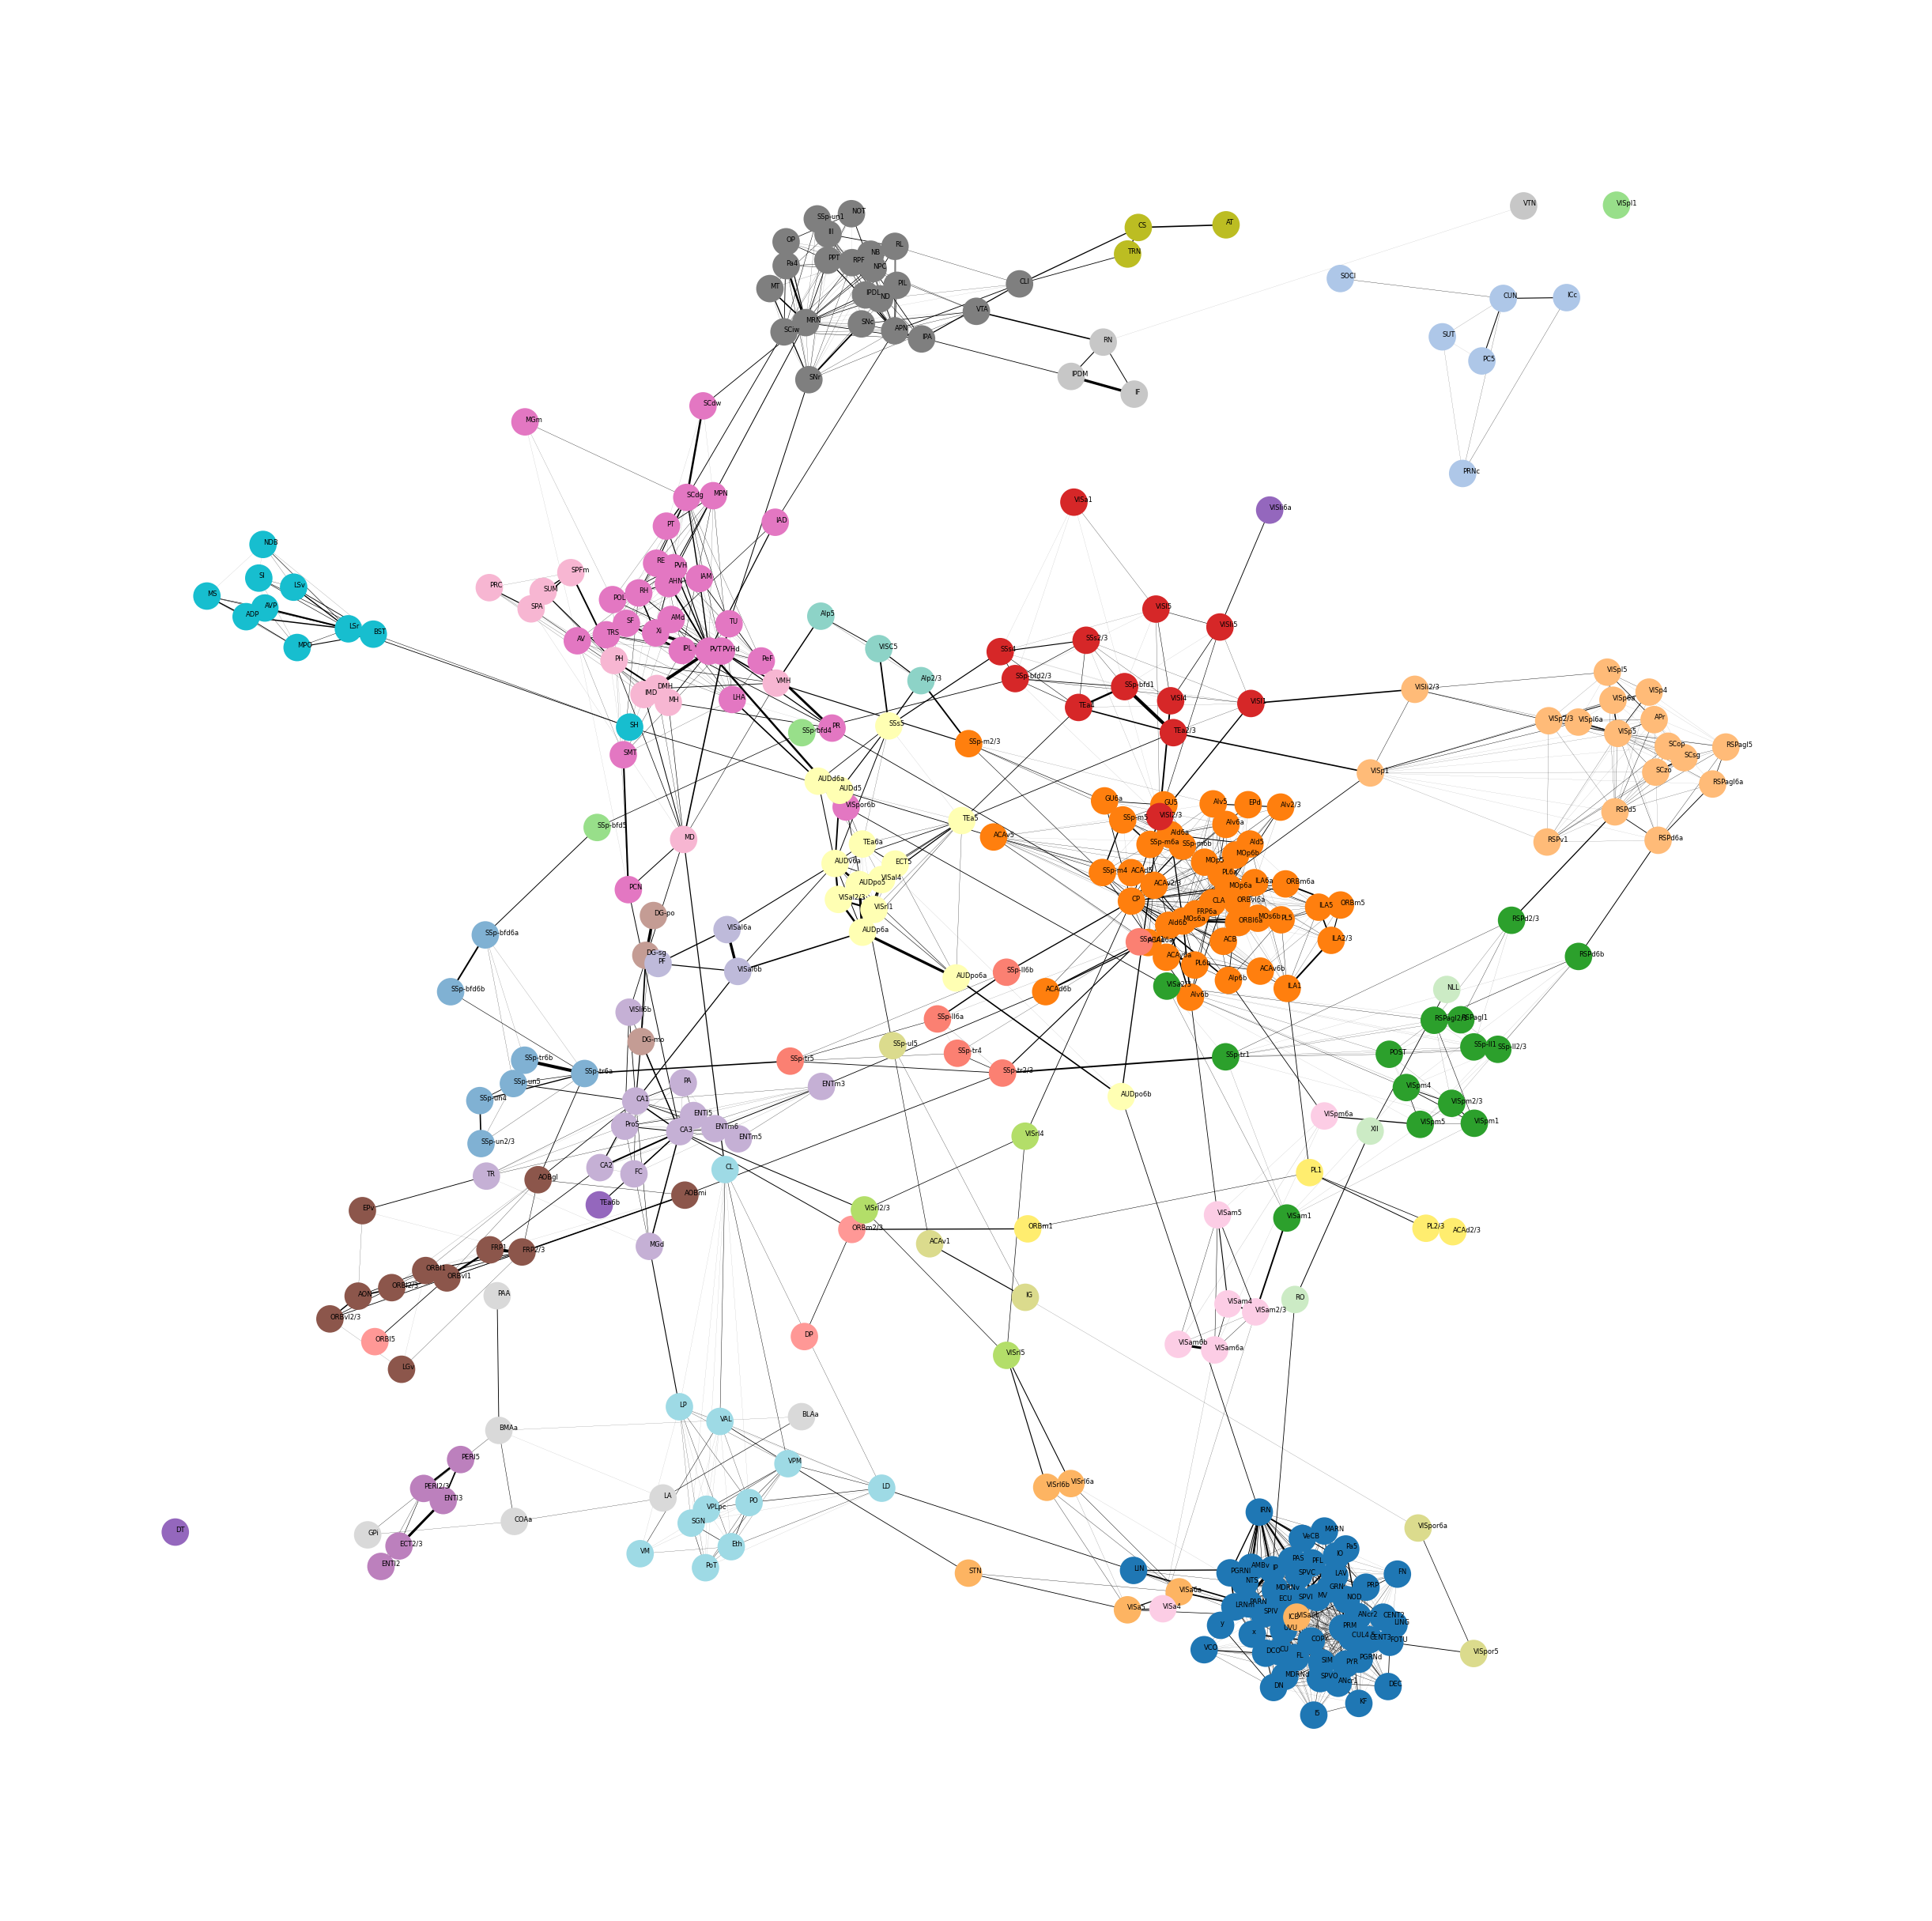

In [19]:
# color_list = sns.color_palette('tab20')
color_list = np.array(color_list)
threshold01 = 0.0
threshold02 = 0.1
threshold03 = 0.1
A = np.copy(Mat_dict['AnyNet'])
A1 = np.zeros((len(acronym_index), len(acronym_index)))
G = nx.Graph()
for ii, acronym_id_ii in enumerate(acronym_index):
    G.add_node(ii)
colors = []
vis_acronym = []
for ii, acronym_id_ii in enumerate(acronym_index):

    for jj, acronym_id_jj in enumerate(acronym_index):
        if acronym_id_ii != acronym_id_jj:
            if A[acronym_id_ii, acronym_id_jj] > threshold01:

                if label_index[ii] == label_index[jj]:
                    try:
                        if G[ii][jj]['weight'] < A[acronym_id_ii, acronym_id_jj]:
                            G[ii][jj]['weight'] = A[acronym_id_ii, acronym_id_jj]
                    except:
                        G.add_edge(ii, jj, weight=A[acronym_id_ii, acronym_id_jj])
                else:
                    if A[acronym_id_ii, acronym_id_jj] > threshold02:
                        try:
                            if G[ii][jj]['weight'] < A[acronym_id_ii, acronym_id_jj]:
                                G[ii][jj]['weight'] = A[acronym_id_ii, acronym_id_jj]
                        except:
                            G.add_edge(ii, jj, weight=A[acronym_id_ii, acronym_id_jj])
                        if A[acronym_id_ii, acronym_id_jj] > threshold03:
                            vis_acronym.append(acronym_name[ii])
                            vis_acronym.append(acronym_name[jj])

            A1[jj, ii] = A[acronym_id_ii, acronym_id_jj]

    if label_index[ii] in marked_community:
        colors.append(color_list[np.argwhere(marked_community == label_index[ii]).flatten()])

edge_width = []
for edge in G.edges:
    edge_width.append(G[edge[0]][edge[1]]['weight'])

vis_acronym_0 = ['CA1', 'CA2', 'CA3', 'ENTl5', 'ENTm5',
               'DG-mo', 'DG-sg', 'DG-po',
               'AT', 'CS', 'TRN',
               'FRP6a', 'MOp5', 'SSp-m5', 'GU5', 'PL5', 'CP',
               'LSr', 'LSv', 'SH', 'SI', 'ADP', 'AVP', 'MPO',
               'LA', 'BMAa', 'PAA',
               'PC5', 'CUN', 'PRNc', 'SUT', 'SOCl',
               'KF', 'I5', 'Pa5', 'MARN', 'MDRNd',
               'PF', 'VISal6a', 'VISal6b',
               'VAL', 'LP', 'VM', 'PoT', 'VPM',
               'FRP1', 'FRP2/3', 'ORBl2/3', 'ORBvl2/3', 'LGv',
               'VISa5',
               'VISp2/3', 'VISp5', 'VISpl5', 'SCop', 'SCsg', 'SCzo',
               'AUDd5', 'AUDpo5', 'VISal2/3', 'TEa5', 'ECT5',
               'ENTl2', 'ENTl3', 'PERI5', 'PERI2/3', 'ECT2/3',
               'SSp-ll2/3', 'VISpm2/3', 'VISpm5', 'RSPd2/3', 'RSPd6b', 'RSPagl2/3']

for acronym in acronym_name:
    vis_acronym.append(acronym)

# vis_acronym = ['CA1', 'CA2', 'CA3', 'ENTl5', 'ENTm5', 'TR', 'MGd',
#                'DG-mo', 'DG-sg', 'DG-po',
#                'AT', 'CS', 'TRN',
#                'FRP6a', 'MOp5', 'SSp-m5', 'GU5', 'ACAd5', 'ACAv5', 'PL5', 'ILA5', 'ORBm5', 'CLA', 'CP',
#                'LSr', 'LSv', 'ADP', 'AVP', 'MPO',
#                'LA', 'BMAa', 'PAA',
#                'PC5', 'CUN', 'PRNc', 'SUT', 'SOCl',]
vis_acronym = np.unique(vis_acronym)
plt.figure(figsize=(5, 5), dpi=600)
pos = nx.spring_layout(G, seed=2)
nx.draw_networkx_nodes(G, pos, node_size=10, node_color=colors, node_shape='o')
nx.draw_networkx_edges(G, pos, width=edge_width, edge_cmap='Blues')
for acronym in vis_acronym:
    pos_acronym = pos[np.argwhere(acronym_name == acronym).flatten().item()]
    plt.text(pos_acronym[0], pos_acronym[1], acronym, fontsize=1)
plt.axis('off')
plt.savefig('/content/drive/MyDrive/Project/BrainRegionId/Svg/graph_rest_all_02.svg')
plt.show()

In [20]:
################################################################################
import subprocess
import sys
required = {'ONE-api', 'brain', 'ibllib'}
subprocess.check_call([sys.executable, '-m', 'pip', 'install', *required])

from one.api import ONE
from brainbox.io.one import SessionLoader, SpikeSortingLoader

from iblatlas.atlas import AllenAtlas

ba = AllenAtlas()
br = ba.regions
ba.compute_regions_volume()

Downloading: /root/Downloads/ONE/openalyx.internationalbrainlab.org/histology/ATLAS/Needles/Allen/average_template_25.nrrd Bytes: 32998960


100%|██████████| 31.470260620117188/31.470260620117188 [00:01<00:00, 16.34it/s]


Downloading: /root/Downloads/ONE/openalyx.internationalbrainlab.org/histology/ATLAS/Needles/Allen/annotation_25.nrrd Bytes: 4035363


100%|██████████| 3.848422050476074/3.848422050476074 [00:01<00:00,  3.84it/s]


In [21]:
acronym_list_Cosmos = [br.acronym2acronym(acronym, mapping='Cosmos')[0] for acronym in acronym_list]
acronym_list_Cosmos = np.array(acronym_list_Cosmos)

In [22]:
Cosmos_list = np.unique(acronym_list_Cosmos)

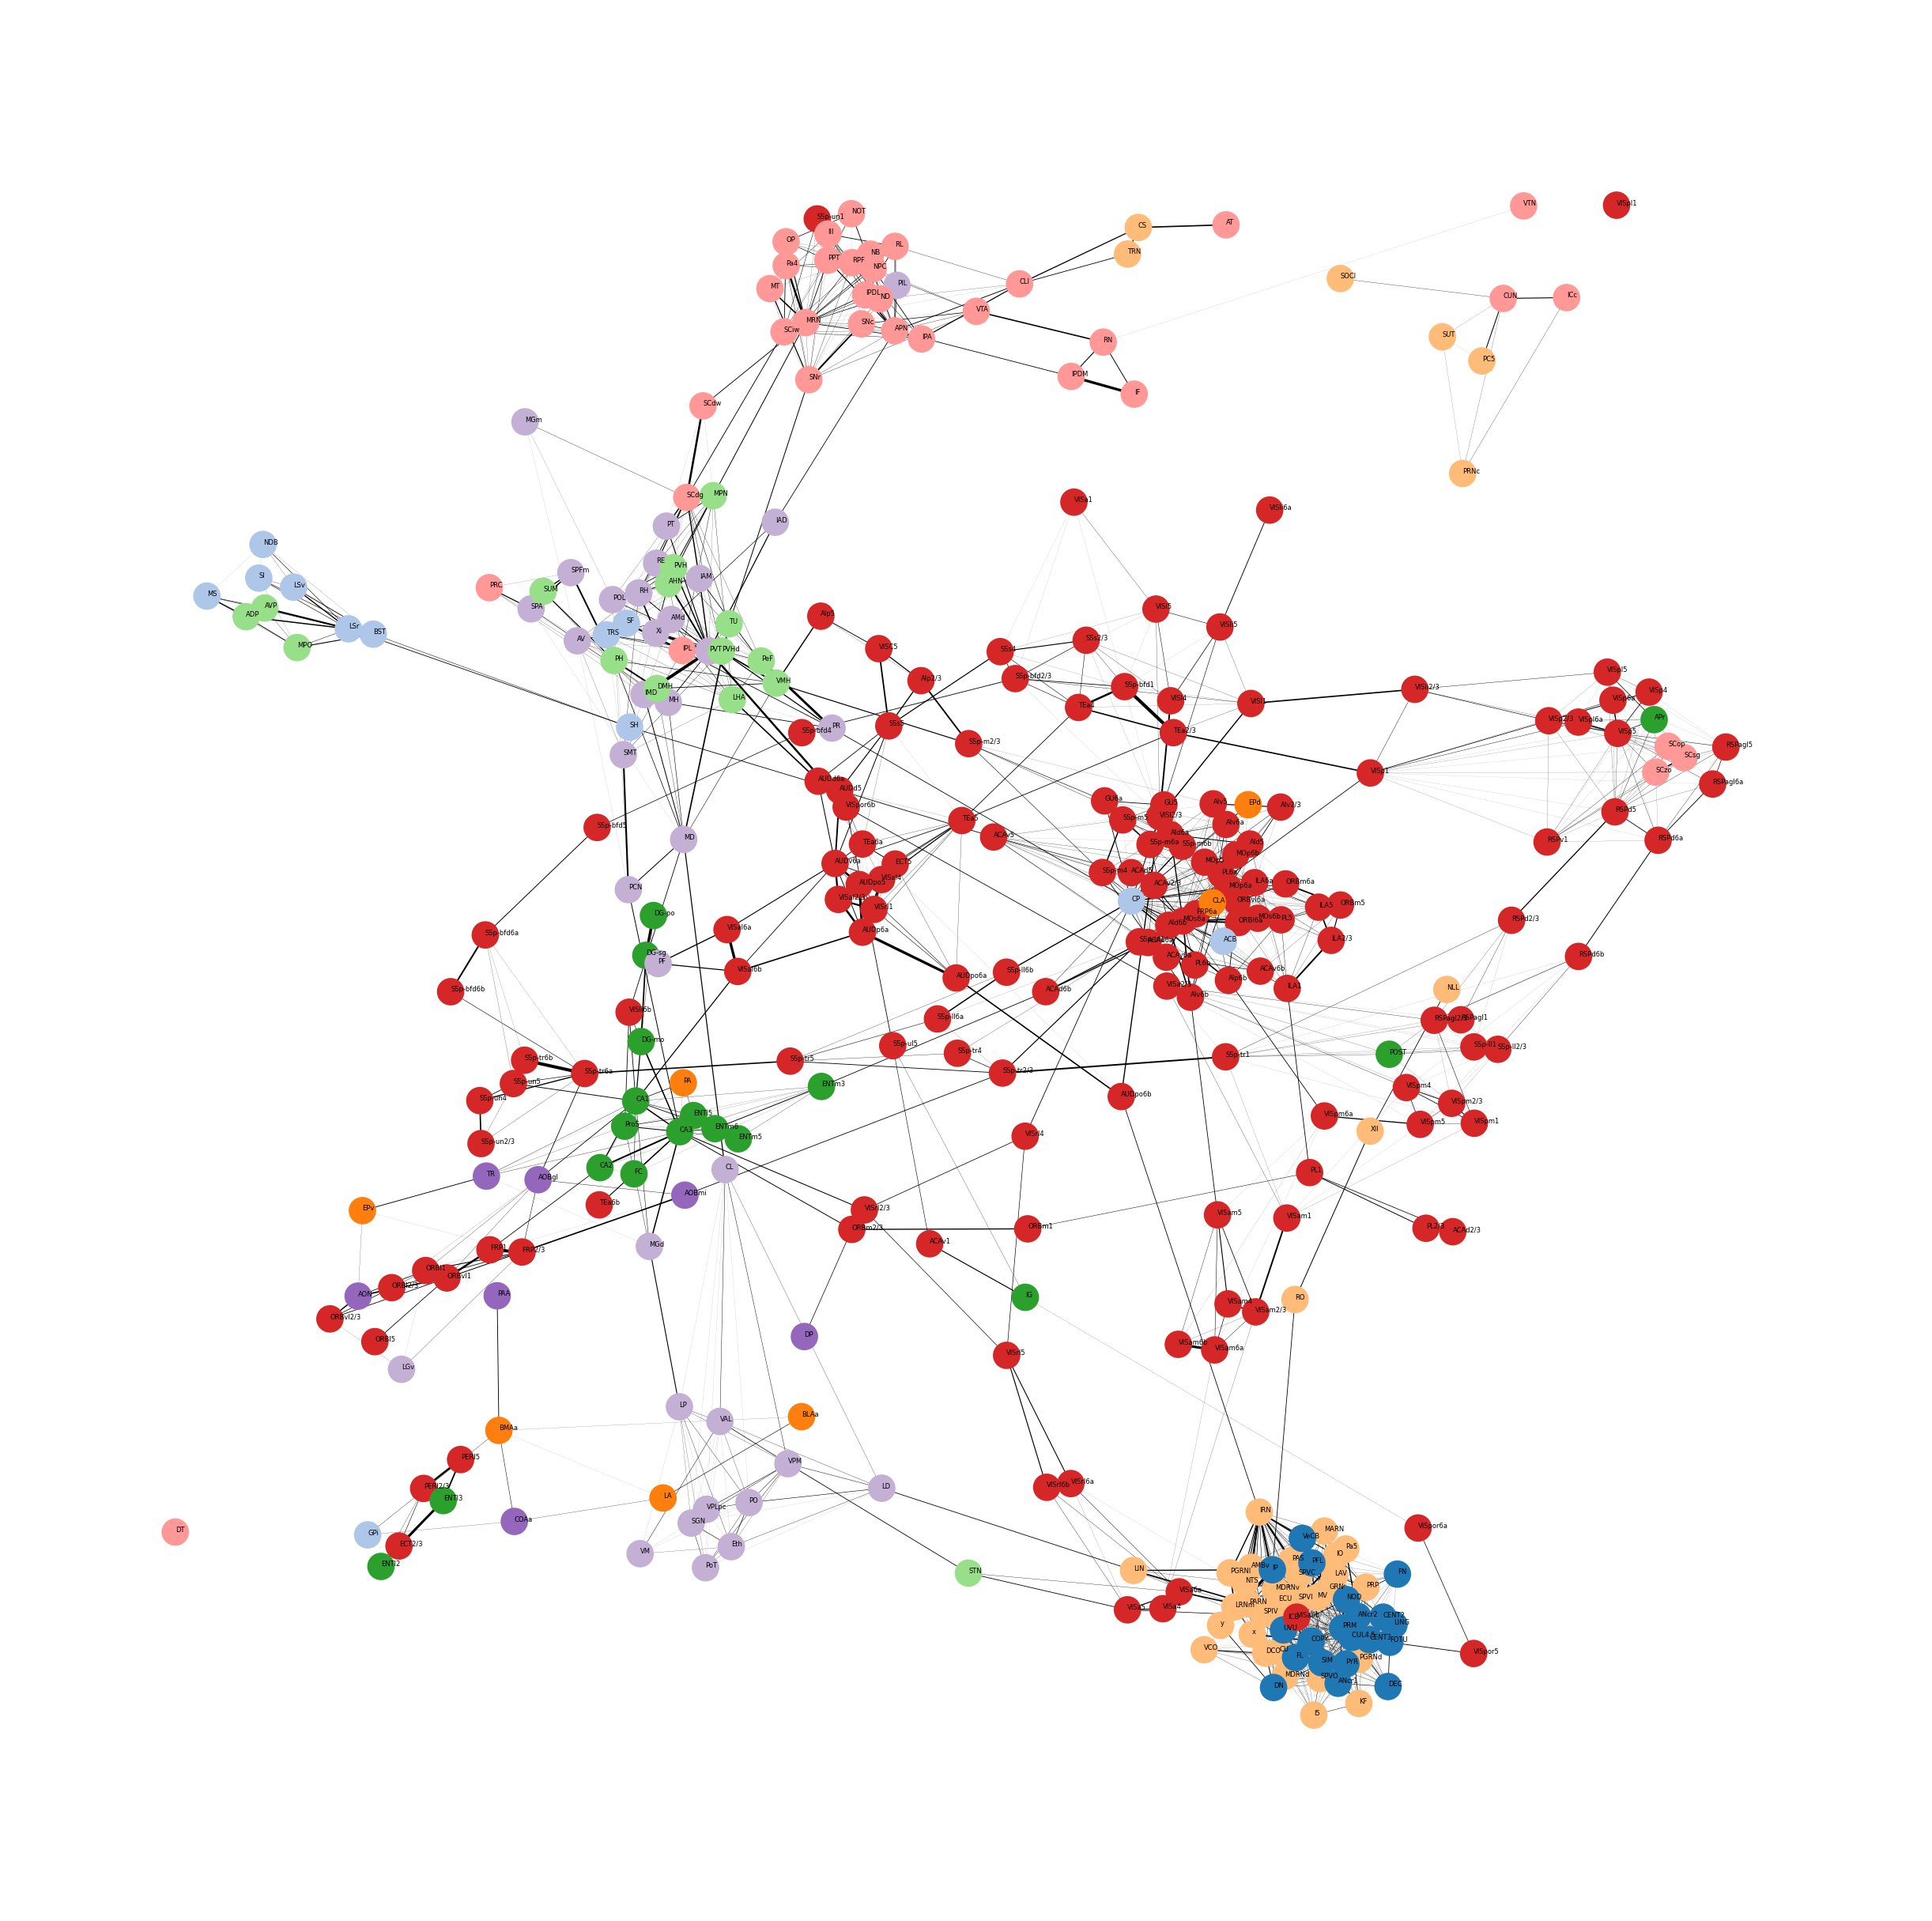

In [24]:
color_list = np.array(color_list)
threshold01 = 0.0
threshold02 = 0.1
threshold03 = 0.1
A = np.copy(Mat_dict['AnyNet'])
A1 = np.zeros((len(acronym_index), len(acronym_index)))
G = nx.Graph()
for ii, acronym_id_ii in enumerate(acronym_index):
    G.add_node(ii)
colors = []
vis_acronym = []
for ii, acronym_id_ii in enumerate(acronym_index):

    for jj, acronym_id_jj in enumerate(acronym_index):
        if acronym_id_ii != acronym_id_jj:
            if A[acronym_id_ii, acronym_id_jj] > threshold01:

                if label_index[ii] == label_index[jj]:
                    try:
                        if G[ii][jj]['weight'] < A[acronym_id_ii, acronym_id_jj]:
                            G[ii][jj]['weight'] = A[acronym_id_ii, acronym_id_jj]
                    except:
                        G.add_edge(ii, jj, weight=A[acronym_id_ii, acronym_id_jj])
                else:
                    if A[acronym_id_ii, acronym_id_jj] > threshold02:
                        try:
                            if G[ii][jj]['weight'] < A[acronym_id_ii, acronym_id_jj]:
                                G[ii][jj]['weight'] = A[acronym_id_ii, acronym_id_jj]
                        except:
                            G.add_edge(ii, jj, weight=A[acronym_id_ii, acronym_id_jj])
                        if A[acronym_id_ii, acronym_id_jj] > threshold03:
                            vis_acronym.append(acronym_name[ii])
                            vis_acronym.append(acronym_name[jj])

            A1[jj, ii] = A[acronym_id_ii, acronym_id_jj]

    colors.append(color_list[np.argwhere(Cosmos_list == acronym_list_Cosmos[acronym_id_ii]).flatten()])

edge_width = []
for edge in G.edges:
    edge_width.append(G[edge[0]][edge[1]]['weight'])

for acronym in acronym_name:
    vis_acronym.append(acronym)

# vis_acronym = ['CA1', 'CA2', 'CA3', 'ENTl5', 'ENTm5', 'TR', 'MGd',
#                'DG-mo', 'DG-sg', 'DG-po',
#                'AT', 'CS', 'TRN',
#                'FRP6a', 'MOp5', 'SSp-m5', 'GU5', 'ACAd5', 'ACAv5', 'PL5', 'ILA5', 'ORBm5', 'CLA', 'CP',
#                'LSr', 'LSv', 'ADP', 'AVP', 'MPO',
#                'LA', 'BMAa', 'PAA',
#                'PC5', 'CUN', 'PRNc', 'SUT', 'SOCl',]
vis_acronym = np.unique(vis_acronym)
plt.figure(figsize=(5, 5), dpi=600)
pos = nx.spring_layout(G, seed=2)
nx.draw_networkx_nodes(G, pos, node_size=10, node_color=colors, node_shape='o')
nx.draw_networkx_edges(G, pos, width=edge_width, edge_cmap='Blues')
for acronym in vis_acronym:
    pos_acronym = pos[np.argwhere(acronym_name == acronym).flatten().item()]
    plt.text(pos_acronym[0], pos_acronym[1], acronym, fontsize=1)
plt.axis('off')
plt.savefig('/content/drive/MyDrive/Project/BrainRegionId/Svg/graph_rest_all_Cosmos02.svg')
plt.show()

In [ ]:
color_list = sns.color_palette('Set3')
color_list = np.array(color_list)
threshold = 0
A = np.copy(Mat_dict['AnyNet'])
A1 = np.zeros((len(acronym_index), len(acronym_index)))
G = nx.Graph()
for ii, acronym_id_ii in enumerate(acronym_index):
    G.add_node(ii)
colors = []
for ii, acronym_id_ii in enumerate(acronym_index):

    for jj, acronym_id_jj in enumerate(acronym_index):
        if acronym_id_ii != acronym_id_jj:
            if A[acronym_id_ii, acronym_id_jj] > threshold:
                try:
                    if G[ii][jj]['weight'] < A[acronym_id_ii, acronym_id_jj]:
                        G[ii][jj]['weight'] = A[acronym_id_ii, acronym_id_jj]
                except:
                    G.add_edge(ii, jj, weight=A[acronym_id_ii, acronym_id_jj])

            A1[jj, ii] = A[acronym_id_ii, acronym_id_jj]


    colors.append(color_list[np.argwhere(Cosmos_list == acronym_list_Cosmos[acronym_id_ii]).flatten()])


edge_width = []
for edge in G.edges:
    edge_width.append(G[edge[0]][edge[1]]['weight'])

vis_acronym = ['CA1', 'CA2', 'CA3', 'ENTl5', 'ENTm5', 'TR', 'MGd', 'ProS',
               'DG-mo', 'DG-sg', 'DG-po',
               'AT', 'CS', 'TRN',
               'FRP6a', 'MOp5', 'MOp6a', 'MOp6b', 'PL6a', 'SSp-m5', 'GU5', 'ACAd5', 'ACAv2/3', 'ACAv5', 'PL5', 'PL6a', 'PL6b', 'ILA5', 'ORBm5', 'GU5', 'CLA', 'CP',
               'LSr', 'LSv', 'SH', 'SI', 'ADP', 'AVP', 'MPO',
               'LA', 'BMAa', 'PAA',
               'PC5', 'CUN', 'PRNc', 'SUT', 'SOCl',
               'KF', 'I5', 'DCO', 'Pa5', 'GRN', 'IRN', 'MARN', 'MDRNd', 'MDRNv', 'FN', 'LING', 'CENT3', 'PRM', 'PFL', 'FL', 'SIM', 'UVU', 'PAS', 'LRNm', 'LIN', 'SPVC',
               'PF', 'VISal6a', 'VISal6b',
               'VAL', 'LP', 'SGN', 'VM', 'PoT', 'VPM', 'PO', 'Eth',
               'FRP1', 'FRP2/3', 'ORBl2/3', 'ORBvl2/3', 'AOBgl', 'AOBmi', 'AON', 'LGv',
               'VISa5',
               'VISp2/3', 'VISp5', 'VISpl5', 'SCop', 'SCsg', 'SCzo',
               'AUDd5', 'AUDpo5', 'VISal2/3', 'TEa5', 'ECT5',
               'ENTl2', 'ENTl3', 'PERI5', 'PERI2/3', 'ECT2/3',
               'SSp-ll2/3', 'VISpm2/3', 'VISpm5', 'RSPd2/3', 'RSPd6b', 'RSPagl2/3']

plt.figure(figsize=(5, 5), dpi=200)
pos = nx.spring_layout(G, scale=1.0, seed=6)
nx.draw_networkx_nodes(G, pos, node_size=20, node_color=colors, node_shape='o')
nx.draw_networkx_edges(G, pos, width=edge_width, edge_cmap='Blues')
for acronym in vis_acronym:
    pos_acronym = pos[np.argwhere(acronym_name == acronym).flatten().item()]
    plt.text(pos_acronym[0], pos_acronym[1], acronym, fontsize=5)
plt.axis('off')
plt.show()

In [ ]:
color_list = sns.color_palette('tab20')
color_list = np.array(color_list)
threshold = 0.05
A = np.copy(Mat_dict['AnyNet'])
A1 = np.zeros((len(acronym_index), len(acronym_index)))
G = nx.Graph()
for ii, acronym_id_ii in enumerate(acronym_index):
    G.add_node(ii)
colors = []
for ii, acronym_id_ii in enumerate(acronym_index):

    for jj, acronym_id_jj in enumerate(acronym_index):
        if acronym_id_ii != acronym_id_jj:
            if A[acronym_id_jj, acronym_id_ii] > threshold:
                try:
                    if G[ii][jj]['weight'] < A[acronym_id_jj, acronym_id_ii]:
                        G[ii][jj]['weight'] = A[acronym_id_jj, acronym_id_ii]
                except:
                    G.add_edge(ii, jj, weight=A[acronym_id_jj, acronym_id_ii])

            A1[jj, ii] = A[acronym_id_jj, acronym_id_ii]

    colors.append(color_list[np.argwhere(marked_community == label_index[ii]).flatten()])

edge_width = []
for edge in G.edges:
    edge_width.append(G[edge[0]][edge[1]]['weight'])

block_line = []
for community_ii, community in enumerate(marked_community):
    ind = np.argwhere(community_dict[resolution]['communities_label'] == community).flatten()
    block_line.append(len(ind))
block_line = np.array(block_line)

# plt.figure(figsize=(2, 2), dpi=200)
# plt.imshow(A1, cmap='bwr')
# for value in np.cumsum(block_line):
#     plt.plot([np.cumsum(block_line), np.cumsum(block_line)], [0, len(acronym_index) - 1], 'k', linewidth=0.1)
#     plt.plot([0, len(acronym_index) - 1], [np.cumsum(block_line), np.cumsum(block_line)], 'k', linewidth=0.1)
# sns.despine()
# plt.show()

plt.figure(figsize=(5, 5), dpi=200)
pos = nx.circular_layout(G)
nx.draw_networkx_nodes(G, pos, node_size=5, node_color=colors, node_shape='o')
nx.draw_networkx_edges(G, pos, width=edge_width, edge_cmap='Blues')
plt.axis('off')
plt.show()

In [ ]:
np.cumsum(block_line)

In [ ]:
A = np.copy(Mat_dict['AnyNet'])


In [ ]:
print(np.size(A2, axis=0))

In [ ]:
G = nx.from_numpy_array(A2)
plt.figure(figsize=(3, 3), dpi=200)
pos = nx.circular_layout(G)
nx.draw_networkx_nodes(G, pos, node_size=10, node_shape='.')
nx.draw_networkx_edges(G, pos, edge_cmap='Greys')
plt.axis('off')
plt.show()

In [ ]:
t = np.random.randn(3, 3)

In [ ]:
t1 = np.copy(t)

In [ ]:
t2 = np.delete(t1, 1, 0)

In [ ]:
print(t)
print(t1)
print(t2)